# Review 2: Pretrained CNN + Temporal Modeling (RNN / LSTM / GRU)
## Video Anomaly Detection — ShanghaiTech Dataset

## 1. Install Dependencies

In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn opencv-python-headless scipy -q
print('All dependencies installed.')

All dependencies installed.


## 2. Imports & Reproducibility

In [2]:
import os, cv2, json, csv, random, gc, time
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, Input, SimpleRNN, LSTM, GRU, Embedding
)
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision enabled (float16)')
except Exception as e:
    print(f'Mixed precision not available: {e}')

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

2026-04-06 15:33:17.236788: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775489597.477115      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775489597.545990      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775489598.128748      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775489598.128791      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775489598.128794      55 computation_placer.cc:177] computation placer alr

Mixed precision enabled (float16)
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 3. Configuration

In [3]:
TEST_ROOT   = '/kaggle/input/datasets/nikanvasei/shanghaitech-campus-dataset-test/SHANGHAI/SHANGHAI_Test'
TEST_FRAMES = os.path.join(TEST_ROOT, 'frames')
TEST_LABELS = os.path.join(TEST_ROOT, 'label')

test_video_ids = []
for entry in os.listdir(TEST_FRAMES):
    full_path = os.path.join(TEST_FRAMES, entry)
    if os.path.isdir(full_path):
        test_video_ids.append(entry)
test_video_ids = sorted(test_video_ids)

CONFIG = {
    'test_frames'          : TEST_FRAMES,
    'test_labels'          : TEST_LABELS,
    'test_video_ids'       : test_video_ids,
    'frame_size'           : (224, 224),
    'sequence_length'      : 16,
    'stride'               : 4,
    'resnet50_feat_dim'    : 2048,
    'densenet121_feat_dim' : 1024,
    'embed_dim'            : 512,
    'hidden_size'          : 256,
    'dropout'              : 0.4,       
    'batch_size'           : 32,
    'epochs'               : 25,        
    'learning_rate'        : 5e-4,      
    'grad_clip'            : 5.0,
    'early_stop_patience'  : 6,
    'normal_anomaly_ratio' : 3,
    'max_normal_test'      : 1500,
    'anomaly_class_weight' : 10.0,
    'finetune_lr'          : 1e-5,
    'finetune_epochs'      : 3,
    'finetune_patience'    : 2,
    'weights_dir'          : '/kaggle/working/results/weights',
    'metrics_dir'          : '/kaggle/working/results/metrics',
    'plots_dir'            : '/kaggle/working/results/plots',
    'summary_dir'          : '/kaggle/working/results/summary',
    'cache_dir'            : '/kaggle/working/results/feature_cache',
}

_common = {
    'sequence_length' : 16,
    'learning_rate'   : 5e-4,
    'dropout'         : 0.4,
    'batch_size'      : 32,
    'hidden_size'     : 256,
    'embed_dim'       : 512,
}
MODEL_HPS = {
    'ResNet50_RNN_ATT'  : {**_common, 'feat_dim': 2048, 'backbone': 'ResNet50',    'rnn_type': 'RNN'},
    'ResNet50_GRU_ATT'  : {**_common, 'feat_dim': 2048, 'backbone': 'ResNet50',    'rnn_type': 'GRU'},
    'ResNet50_LSTM_ATT' : {**_common, 'feat_dim': 2048, 'backbone': 'ResNet50',    'rnn_type': 'LSTM'},
    'DenseNet_RNN_ATT'  : {**_common, 'feat_dim': 1024, 'backbone': 'DenseNet121', 'rnn_type': 'RNN'},
    'DenseNet_GRU_ATT'  : {**_common, 'feat_dim': 1024, 'backbone': 'DenseNet121', 'rnn_type': 'GRU'},
    'DenseNet_LSTM_ATT' : {**_common, 'feat_dim': 1024, 'backbone': 'DenseNet121', 'rnn_type': 'LSTM'},
}

os.makedirs(CONFIG['weights_dir'], exist_ok=True)
os.makedirs(CONFIG['metrics_dir'], exist_ok=True)
os.makedirs(CONFIG['plots_dir'],   exist_ok=True)
os.makedirs(CONFIG['summary_dir'], exist_ok=True)
os.makedirs(CONFIG['cache_dir'],   exist_ok=True)

print(f'Videos   : {len(test_video_ids)}')
print(f'LR            : {CONFIG["learning_rate"]}  (same for all models)')
print(f'Dropout       : {CONFIG["dropout"]}  (same for all models)')
print(f'Epochs        : {CONFIG["epochs"]}  (early stop patience={CONFIG["early_stop_patience"]})')
print(f'Fine-tune LR  : {CONFIG["finetune_lr"]}  for {CONFIG["finetune_epochs"]} epochs')

Videos   : 199
LR            : 0.0005  (same for all models)
Dropout       : 0.4  (same for all models)
Epochs        : 25  (early stop patience=6)
Fine-tune LR  : 1e-05  for 3 epochs


## 4. Ground Truth Labels

In [4]:
def load_ground_truth(video_ids, label_dir):
    if not os.path.isdir(label_dir):
        raise FileNotFoundError(f'Label directory not found: {label_dir}')

    label_files = {}
    for filename in os.listdir(label_dir):
        if filename.endswith('.npy'):
            video_id_key = os.path.splitext(filename)[0]
            label_files[video_id_key] = filename

    gt_labels = {}
    for vid_id in video_ids:
        if vid_id in label_files:
            label_path     = os.path.join(label_dir, label_files[vid_id])
            raw_labels     = np.load(label_path)
            gt_labels[vid_id] = raw_labels.astype(int).flatten()

    n_anom = 0
    for vid in gt_labels:
        if gt_labels[vid].sum() > 0:
            n_anom += 1

    print(f'GT loaded: {len(gt_labels)}/{len(video_ids)} videos  |  {n_anom} contain anomalies')
    return gt_labels


GT_LABELS = load_ground_truth(CONFIG['test_video_ids'], TEST_LABELS)

GT loaded: 199/199 videos  |  44 contain anomalies


## 5. Temporal Data Preprocessing Pipeline

In [5]:
def build_sequences(video_ids, frames_dir, gt_labels, seq_len, stride):
    sequences = []

    for vid_id in video_ids:
        frame_dir = os.path.join(frames_dir, vid_id)
        if not os.path.isdir(frame_dir):
            continue

        frames = []
        for filename in os.listdir(frame_dir):
            if filename.lower().endswith('.jpg'):
                frames.append(os.path.join(frame_dir, filename))
        frames = sorted(frames)
        
        if len(frames) < seq_len:
            continue

        if vid_id in gt_labels:
            gt = gt_labels[vid_id]

            if len(gt) < len(frames):
                gt = np.pad(gt, (0, len(frames) - len(gt)))
            else:
                gt = gt[:len(frames)]
        else:
            gt = np.zeros(len(frames), dtype=int)

        for start in range(0, len(frames) - seq_len + 1, stride):
            end         = start + seq_len
            window_lbls = gt[start:end]

            window_label = 1 if np.mean(window_lbls) > 0.5 else 0

            meta = {'video_id': vid_id, 'start': start, 'end': end}
            sequences.append((frames[start:end], window_label, meta))

    return sequences

In [6]:
def undersample_normal(sequences, ratio, seed=SEED):

    rng = np.random.RandomState(seed)

    anomaly_seqs = []
    normal_seqs  = []
    for seq in sequences:
        if seq[1] == 1:
            anomaly_seqs.append(seq)
        else:
            normal_seqs.append(seq)

    # How many normal sequences to keep
    target_count = min(len(normal_seqs), ratio * len(anomaly_seqs))
    chosen_idx   = rng.choice(len(normal_seqs), size=int(target_count), replace=False)

    kept_normal = []
    for idx in sorted(chosen_idx):
        kept_normal.append(normal_seqs[idx])

    return kept_normal + anomaly_seqs

In [7]:
def cap_normal(sequences, max_normal, seed=SEED):
    rng = np.random.RandomState(seed)

    anomaly_seqs = []
    normal_seqs  = []
    for seq in sequences:
        if seq[1] == 1:
            anomaly_seqs.append(seq)
        else:
            normal_seqs.append(seq)

    n_keep     = min(max_normal, len(normal_seqs))
    chosen_idx = rng.choice(len(normal_seqs), size=n_keep, replace=False)

    kept_normal = []
    for idx in sorted(chosen_idx):
        kept_normal.append(normal_seqs[idx])

    return kept_normal + anomaly_seqs

## 6. Video-Level Train / Val / Test Split

In [8]:
SEQ_LEN = CONFIG['sequence_length']
STRIDE  = CONFIG['stride']

all_test_seqs = build_sequences(
    CONFIG['test_video_ids'], TEST_FRAMES, GT_LABELS, SEQ_LEN, STRIDE
)

unique_vids = []
seen_vids   = set()
for _, _, meta in all_test_seqs:
    vid = meta['video_id']
    if vid not in seen_vids:
        unique_vids.append(vid)
        seen_vids.add(vid)
unique_vids = sorted(unique_vids)

vid_has_anomaly = {}
for vid in unique_vids:
    has_anomaly = False
    for _, label, meta in all_test_seqs:
        if meta['video_id'] == vid and label == 1:
            has_anomaly = True
            break
    vid_has_anomaly[vid] = has_anomaly

vid_flags = []
for vid in unique_vids:
    if vid_has_anomaly[vid]:
        vid_flags.append(1)
    else:
        vid_flags.append(0)

In [9]:
# Video-level split: 70% train+val, 30% held-out test
if len(set(vid_flags)) > 1:
    trainval_vids, heldout_vids = train_test_split(
        unique_vids, test_size=0.3, stratify=vid_flags, random_state=SEED
    )
else:
    trainval_vids, heldout_vids = train_test_split(
        unique_vids, test_size=0.3, random_state=SEED
    )

trainval_set = set(trainval_vids)
heldout_set  = set(heldout_vids)

trainval_seqs = []
test_seqs_raw = []
for paths, label, meta in all_test_seqs:
    if meta['video_id'] in trainval_set:
        trainval_seqs.append((paths, label, meta))
    else:
        test_seqs_raw.append((paths, label, meta))

# 80/20 sequence-level split within train+val pool
tv_labels = []
for _, label, _ in trainval_seqs:
    tv_labels.append(label)
tv_indices = list(range(len(trainval_seqs)))

if len(set(tv_labels)) > 1:
    train_idx, val_idx = train_test_split(
        tv_indices, test_size=0.2, stratify=tv_labels, random_state=SEED
    )
else:
    train_idx, val_idx = train_test_split(
        tv_indices, test_size=0.2, random_state=SEED
    )

# Collect train and val sequences by index
train_seqs_full = []
for i in train_idx:
    train_seqs_full.append(trainval_seqs[i])

val_seqs = []
for i in val_idx:
    val_seqs.append(trainval_seqs[i])

test_seqs = test_seqs_raw

train_seqs = undersample_normal(
    train_seqs_full,
    ratio=CONFIG['normal_anomaly_ratio'],
    seed=SEED
)
random.seed(SEED)
random.shuffle(train_seqs)

test_seqs_balanced = cap_normal(test_seqs, CONFIG['max_normal_test'], seed=SEED)
random.seed(SEED)
random.shuffle(test_seqs_balanced)

In [10]:
# Build label arrays from each split
y_train = []
for _, label, _ in train_seqs:
    y_train.append(label)
y_train = np.array(y_train, dtype=np.float32)

y_val = []
for _, label, _ in val_seqs:
    y_val.append(label)
y_val = np.array(y_val, dtype=np.float32)

y_test = []
for _, label, _ in test_seqs:
    y_test.append(label)
y_test = np.array(y_test, dtype=np.float32)

y_test_balanced = []
for _, label, _ in test_seqs_balanced:
    y_test_balanced.append(label)
y_test_balanced = np.array(y_test_balanced, dtype=np.float32)

n_train_anom = int(y_train.sum())
n_val_anom   = int(y_val.sum())
n_test_anom  = int(y_test_balanced.sum())
print(f'Train : {len(train_seqs):5d} sequences  Normal={len(train_seqs)-n_train_anom}  Anomaly={n_train_anom}')
print(f'Val   : {len(val_seqs):5d} sequences  Normal={len(val_seqs)-n_val_anom}  Anomaly={n_val_anom}')
print(f'Test  : {len(test_seqs_balanced):5d} sequences  Normal={len(test_seqs_balanced)-n_test_anom}  Anomaly={n_test_anom}')

Train :  4716 sequences  Normal=3537  Anomaly=1179
Val   :  4929 sequences  Normal=4634  Anomaly=295
Test  :  1991 sequences  Normal=1500  Anomaly=491


## 7. Sample Sequence Visualisation

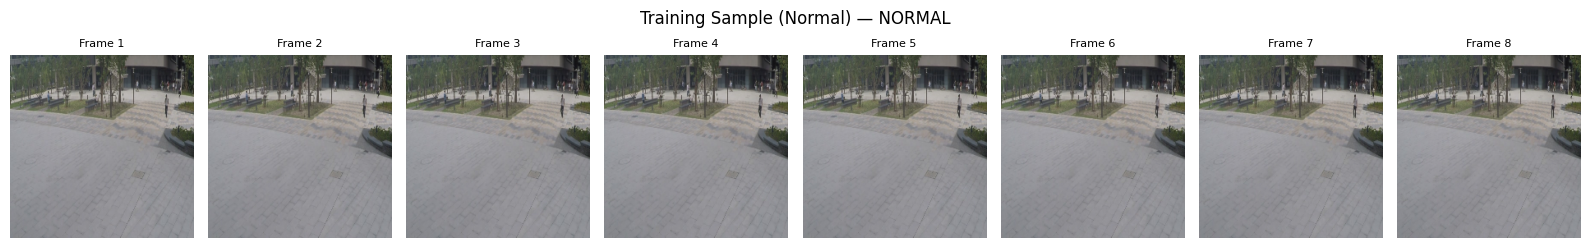

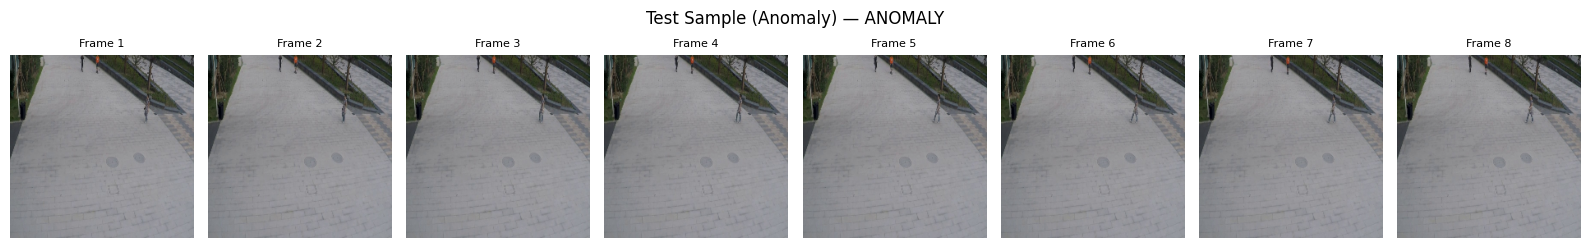

In [11]:
def show_sequence(sequences, idx=0, title='Sample'):
    paths, label, _ = sequences[idx]
    n_show = min(8, len(paths))

    if label > 0.5:
        lbl_text = 'ANOMALY'
    else:
        lbl_text = 'NORMAL'

    fig, axes = plt.subplots(1, n_show, figsize=(16, 2.5))
    fig.suptitle(f'{title} — {lbl_text}', fontsize=12)

    for i in range(n_show):
        img = cv2.cvtColor(cv2.imread(paths[i]), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, CONFIG['frame_size'])

        if n_show > 1:
            ax = axes[i]
        else:
            ax = axes

        ax.imshow(img)
        ax.set_title(f'Frame {i+1}', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['plots_dir'], 'sample_sequence.png'), dpi=120)
    plt.show()

normal_idxs = []
for i, (_, label, _) in enumerate(train_seqs):
    if label == 0:
        normal_idxs.append(i)

anomaly_idxs = []
for i, (_, label, _) in enumerate(all_test_seqs):
    if label == 1:
        anomaly_idxs.append(i)

if normal_idxs:
    show_sequence(train_seqs,    idx=normal_idxs[0],  title='Training Sample (Normal)')
if anomaly_idxs:
    show_sequence(all_test_seqs, idx=anomaly_idxs[0], title='Test Sample (Anomaly)')

## 8. CNN Feature Extractors — Feature Extraction (Pretrained CNNs)

In [12]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

_H, _W = CONFIG['frame_size'][1], CONFIG['frame_size'][0]


def _tf_load_frame(path):
    raw = tf.io.read_file(path)
    img = tf.io.decode_jpeg(
        raw, channels=3,
        try_recover_truncated=True,
        acceptable_fraction=0.0
    )
    img = tf.image.resize(img, [_H, _W])
    img = tf.cast(img, tf.float32) / 255.0
    return (img - IMAGENET_MEAN) / IMAGENET_STD


def build_frozen_resnet50():
    base = ResNet50(
        weights     = 'imagenet',
        include_top = False,
        pooling     = 'avg',
        input_shape = (224, 224, 3)
    )
    base.trainable = False
    return Model(inputs=base.input, outputs=base.output, name='ResNet50_frozen')


def build_frozen_densenet121():
    base = DenseNet121(
        weights     = 'imagenet',
        include_top = False,
        pooling     = 'avg',
        input_shape = (224, 224, 3)
    )
    base.trainable = False
    return Model(inputs=base.input, outputs=base.output, name='DenseNet121_frozen')

In [13]:
def extract_features(sequences, cnn_model, cnn_name, batch_size=32, cache_path=None):
    if cache_path and os.path.exists(cache_path):
        print(f'  [{cnn_name}] Loading cached features from {cache_path}')
        return dict(np.load(cache_path, allow_pickle=True).item())

    unique_path_set = set()
    for seq_paths, _, _ in sequences:
        for p in seq_paths:
            unique_path_set.add(p)
    all_paths = sorted(unique_path_set)

    print(f'  [{cnn_name}] Extracting {len(all_paths):,} unique frames...')

    path_ds = tf.data.Dataset.from_tensor_slices(all_paths)
    img_ds  = (
        path_ds
        .map(_tf_load_frame, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(2)
    )

    cache = {}
    idx   = 0
    t0    = time.time()

    for batch_imgs in img_ds:
        batch_feats = cnn_model(tf.cast(batch_imgs, tf.float32), training=False).numpy()
        for feat in batch_feats:
            cache[all_paths[idx]] = feat
            idx += 1

    print(f'  [{cnn_name}] Done in {time.time()-t0:.1f}s  dim={list(cache.values())[0].shape}')

    if cache_path:
        np.save(cache_path, cache)

    return cache

## 9. Fine-Tuning Pretrained CNNs

In [14]:
def finetune_cnn(base_model, block_keyword, model_name, train_seqs, n_frames=600):
    for layer in base_model.layers:
        if block_keyword in layer.name:
            layer.trainable = True

    trainable_count = 0
    for w in base_model.trainable_weights:
        trainable_count += tf.keras.backend.count_params(w)

    total_count = 0
    for w in base_model.weights:
        total_count += tf.keras.backend.count_params(w)

    print(f'  {model_name}: {int(trainable_count):,} / {int(total_count):,} params trainable ({block_keyword} unfrozen)')

    rng     = np.random.RandomState(SEED)
    indices = list(range(len(train_seqs)))
    rng.shuffle(indices)

    ft_frames = []
    ft_labels = []
    for i in indices[:n_frames]:
        paths, label, _ = train_seqs[i]
        mid = len(paths) // 2
        img = cv2.cvtColor(cv2.imread(paths[mid]), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, CONFIG['frame_size']).astype(np.float32) / 255.0
        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        ft_frames.append(img)
        ft_labels.append(float(label))

    ft_X = np.array(ft_frames, dtype=np.float32)
    ft_y = np.array(ft_labels, dtype=np.float32)
    del ft_frames
    gc.collect()

    n_anomaly = int(ft_y.sum())
    n_normal  = len(ft_y) - n_anomaly
    print(f'  Fine-tune set: {len(ft_X)} frames  Normal={n_normal}  Anomaly={n_anomaly}')

    ft_out   = Dense(1, activation='sigmoid', dtype='float32', name='ft_head')(base_model.output)
    ft_model = Model(inputs=base_model.input, outputs=ft_out)
    ft_model.compile(
        optimizer = Adam(learning_rate=CONFIG['finetune_lr'], clipnorm=5.0),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )

    ft_ds = (
        tf.data.Dataset.from_tensor_slices((ft_X, ft_y))
        .shuffle(len(ft_X), seed=SEED)
        .batch(16)
        .prefetch(tf.data.AUTOTUNE)
    )

    ft_callbacks = [
        EarlyStopping(
            monitor             = 'loss',
            patience            = CONFIG['finetune_patience'],
            restore_best_weights= True,
            verbose             = 1
        )
    ]

    print(f'  Fine-tuning {model_name} ({block_keyword}) for up to {CONFIG["finetune_epochs"]} epochs...')
    ft_model.fit(ft_ds, epochs=CONFIG['finetune_epochs'], callbacks=ft_callbacks, verbose=1)

    del ft_model
    del ft_X
    del ft_y
    del ft_ds
    gc.collect()
    print(f'  {model_name} fine-tuning complete. Temporary head removed.\n')

    return base_model

In [15]:
print('Building and fine-tuning CNN backbones...\n')
dummy        = tf.cast(tf.random.normal((2, 224, 224, 3)), tf.float32)
resnet50_base    = build_frozen_resnet50()
densenet121_base = build_frozen_densenet121()
print(f'ResNet50 output shape    : {resnet50_base(dummy, training=False).shape}')
print(f'DenseNet121 output shape : {densenet121_base(dummy, training=False).shape}\n')

print('DenseNet121 last 20 layer names:')
for layer in densenet121_base.layers[-20:]:
    print(f'  {layer.name}')
print()

resnet50_base    = finetune_cnn(resnet50_base,    'conv5_block', 'ResNet50',    train_seqs)
densenet121_base = finetune_cnn(densenet121_base, 'conv5_block', 'DenseNet121', train_seqs)
print('Both backbones fine-tuned and ready for feature extraction.')

Building and fine-tuning CNN backbones...



I0000 00:00:1775489638.512438      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775489638.518413      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1775489644.715431      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


ResNet50 output shape    : (2, 2048)
DenseNet121 output shape : (2, 1024)

DenseNet121 last 20 layer names:
  conv5_block14_1_relu
  conv5_block14_2_conv
  conv5_block14_concat
  conv5_block15_0_bn
  conv5_block15_0_relu
  conv5_block15_1_conv
  conv5_block15_1_bn
  conv5_block15_1_relu
  conv5_block15_2_conv
  conv5_block15_concat
  conv5_block16_0_bn
  conv5_block16_0_relu
  conv5_block16_1_conv
  conv5_block16_1_bn
  conv5_block16_1_relu
  conv5_block16_2_conv
  conv5_block16_concat
  bn
  relu
  avg_pool

  ResNet50: 14,976,000 / 23,587,712 params trainable (conv5_block unfrozen)
  Fine-tune set: 600 frames  Normal=453  Anomaly=147
  Fine-tuning ResNet50 (conv5_block) for up to 3 epochs...
Epoch 1/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.8012 - loss: 0.4557
Epoch 2/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9185 - loss: 0.2304
Epoch 3/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9467 - loss: 0.1661
Restoring model weights from the end of the 

## 10. Feature Pre-Extraction & Caching

In [16]:
r50_cache_path = os.path.join(CONFIG['cache_dir'], 'resnet50_ft_cache.npy')
dn_cache_path  = os.path.join(CONFIG['cache_dir'], 'densenet121_ft_cache.npy')

all_seqs = train_seqs + val_seqs + test_seqs
print(f'Total sequences for caching: {len(all_seqs)}')

print('\nExtracting ResNet50 (fine-tuned) features...')
resnet50_cache    = extract_features(all_seqs, resnet50_base,    'ResNet50-FT',    batch_size=32, cache_path=r50_cache_path)

print('Extracting DenseNet121 (fine-tuned) features...')
densenet121_cache = extract_features(all_seqs, densenet121_base, 'DenseNet121-FT', batch_size=32, cache_path=dn_cache_path)

del resnet50_base, densenet121_base; gc.collect()
print('\nCNN models freed. Feature caches ready.')

Total sequences for caching: 19847

Extracting ResNet50 (fine-tuned) features...
  [ResNet50-FT] Extracting 124,364 unique frames...
  [ResNet50-FT] Done in 1102.2s  dim=(2048,)
Extracting DenseNet121 (fine-tuned) features...
  [DenseNet121-FT] Extracting 124,364 unique frames...
  [DenseNet121-FT] Done in 1937.1s  dim=(1024,)

CNN models freed. Feature caches ready.


## 11. Feature Arrays & tf.data Pipelines

In [17]:
def sequences_to_arrays(sequences, feature_cache, feat_dim, seq_len):

    n = len(sequences)
    X = np.zeros((n, seq_len, feat_dim), dtype=np.float32)
    y = np.zeros(n, dtype=np.float32)

    for i, (paths, label, _) in enumerate(sequences):
        for t, p in enumerate(paths[:seq_len]):
            X[i, t] = feature_cache[p]
        y[i] = label

    return X, y

def make_tf_dataset(X, y, batch_size, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))

    if shuffle:
        buffer_size = min(len(X), 10000)
        dataset     = dataset.shuffle(buffer_size=buffer_size, seed=SEED)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

## 12. Embedding, Positional Encoding & Attention

In [18]:
class PositionalEmbeddingLayer(tf.keras.layers.Layer):
    def __init__(self, seq_len, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.seq_len   = seq_len
        self.embed_dim = embed_dim
        self.embedding = Embedding(seq_len, embed_dim)

    def call(self, x):
        B   = tf.shape(x)[0]
        pos = tf.expand_dims(tf.range(tf.shape(x)[1]), 0)
        pos = tf.tile(pos, [B, 1])
        return x + self.embedding(pos)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'seq_len': self.seq_len, 'embed_dim': self.embed_dim})
        return cfg


class AdditiveAttentionLayer(tf.keras.layers.Layer):
    def __init__(self, dropout_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.dropout_rate = dropout_rate
        self.score_dense  = Dense(1, activation='tanh', name='attn_score')
        self.dropout      = Dropout(dropout_rate)

    def call(self, x, training=False):
        scores  = self.score_dense(x)                       # (B, T, 1)
        weights = tf.nn.softmax(scores, axis=1)             # (B, T, 1)
        weights = self.dropout(weights, training=training)
        return tf.reduce_sum(weights * x, axis=1)           # (B, hidden)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'dropout_rate': self.dropout_rate})
        return cfg

print('PositionalEmbeddingLayer and AdditiveAttentionLayer defined.')

PositionalEmbeddingLayer and AdditiveAttentionLayer defined.


## 13. Temporal Classifier Architecture

In [19]:
def build_temporal_classifier(rnn_type='LSTM', feat_dim=2048, hp=None):
    hp        = hp or {}
    seq_len   = hp.get('sequence_length', CONFIG['sequence_length'])
    embed_dim = hp.get('embed_dim',       CONFIG['embed_dim'])
    hidden    = hp.get('hidden_size',     CONFIG['hidden_size'])
    drop      = hp.get('dropout',         CONFIG['dropout'])

    inp = Input(shape=(seq_len, feat_dim), name='feature_input')

    x = Dense(embed_dim, activation='relu', name='input_embedding')(inp)
    x = Dropout(drop, name='proj_drop')(x)

    x = PositionalEmbeddingLayer(seq_len, embed_dim, name='pos_embed')(x)

    rnn_kw = dict(units=hidden, dropout=drop, recurrent_dropout=0.0, return_sequences=True)

    if rnn_type == 'RNN':
        x = SimpleRNN(**rnn_kw, name='rnn_1')(x)
        x = SimpleRNN(**rnn_kw, name='rnn_2')(x)
    elif rnn_type == 'GRU':
        x = GRU(**rnn_kw, name='gru_1')(x)
        x = GRU(**rnn_kw, name='gru_2')(x)
    else:
        x = LSTM(**rnn_kw, name='lstm_1')(x)
        x = LSTM(**rnn_kw, name='lstm_2')(x)

    x = AdditiveAttentionLayer(dropout_rate=drop, name='additive_attn')(x)

    x   = Dense(128, activation='relu', name='fc1')(x)
    x   = Dropout(drop, name='fc_drop')(x)
    out = Dense(1, activation='sigmoid', dtype='float32', name='output')(x)

    return Model(inputs=inp, outputs=out, name=f'{rnn_type}_ATT_{feat_dim}d')

print('All 6 model variants:')
for name, hp in MODEL_HPS.items():
    m  = build_temporal_classifier(hp['rnn_type'], hp['feat_dim'], hp)

    trainable_params = 0
    for w in m.trainable_weights:
        trainable_params += tf.keras.backend.count_params(w)

    print(f'{name:<22}  feat={hp["feat_dim"]}  params={int(trainable_params):,}')
    del m
gc.collect()

All 6 model variants:
ResNet50_RNN_ATT        feat=2048  params=1,418,754
ResNet50_GRU_ATT        feat=2048  params=2,076,674
ResNet50_LSTM_ATT       feat=2048  params=2,403,330
DenseNet_RNN_ATT        feat=1024  params=894,466
DenseNet_GRU_ATT        feat=1024  params=1,552,386
DenseNet_LSTM_ATT       feat=1024  params=1,879,042


8570

## 14. Training Function

In [20]:
def find_optimal_threshold(model, val_ds, y_val_arr):
    probs = model.predict(val_ds, verbose=0).flatten()

    best_f1     = 0.0
    best_thresh = 0.5

    threshold = 0.01
    while threshold < 0.80:
        preds = (probs > threshold).astype(int)
        score = f1_score(y_val_arr.astype(int), preds, zero_division=0)

        if score > best_f1:
            best_f1     = score
            best_thresh = round(float(threshold), 2)

        threshold = round(threshold + 0.01, 2)

    return best_thresh, best_f1

In [21]:
def train_model(rnn_type, feat_dim, train_ds, val_ds, model_name, y_val_arr=None, hp=None):

    hp = hp or {}
    lr = hp.get('learning_rate', CONFIG['learning_rate'])

    print(f'\n{"="*70}')
    print(f'  Training: {model_name}  |  backbone={hp.get("backbone")}  rnn={rnn_type}  feat={feat_dim}')
    print(f'  LR={lr}  dropout={hp.get("dropout", CONFIG["dropout"])}  epochs={CONFIG["epochs"]}')
    print(f'{"="*70}')

    model = build_temporal_classifier(rnn_type=rnn_type, feat_dim=feat_dim, hp=hp)
    model.compile(
        optimizer = Adam(learning_rate=lr, clipnorm=CONFIG['grad_clip']),
        loss      = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0),
        metrics   = ['accuracy']
    )
    model.summary()

    ckpt_path    = os.path.join(CONFIG['weights_dir'], f'best_{model_name}.keras')
    weights_path = os.path.join(CONFIG['weights_dir'], f'best_{model_name}.weights.h5')

    callbacks = [
        EarlyStopping(
            monitor             = 'val_loss',
            patience            = CONFIG['early_stop_patience'],
            restore_best_weights= True,
            verbose             = 1
        ),
        ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = 5,
            verbose  = 1,
            min_lr   = 1e-7
        ),
        ModelCheckpoint(ckpt_path,    monitor='val_loss', save_best_only=True, verbose=0),
        ModelCheckpoint(weights_path, monitor='val_loss', save_best_only=True,
                        save_weights_only=True, verbose=0),
    ]

    t0 = time.time()
    history = model.fit(
        train_ds,
        validation_data = val_ds,
        epochs          = CONFIG['epochs'],
        callbacks       = callbacks,
        class_weight    = {0: 1.0, 1: CONFIG['anomaly_class_weight']},
        verbose         = 1
    )
    elapsed = time.time() - t0

    best_val = min(history.history['val_loss'])
    best_ep  = int(np.argmin(history.history['val_loss'])) + 1
    print(f'\n{model_name}: best val_loss={best_val:.4f} @ epoch {best_ep}  ({elapsed:.0f}s total)')

    history_data = {}
    for key, values in history.history.items():
        history_data[key] = []
        for v in values:
            history_data[key].append(float(v))

    hp_used = {
        'learning_rate' : hp.get('learning_rate'),
        'dropout'       : hp.get('dropout'),
        'batch_size'    : hp.get('batch_size'),
        'feat_dim'      : feat_dim,
    }

    metrics_out = {
        'model'          : model_name,
        'backbone'       : hp.get('backbone'),
        'rnn_type'       : rnn_type,
        'best_val_loss'  : float(best_val),
        'best_epoch'     : best_ep,
        'train_time_sec' : round(elapsed, 1),
        'hyperparameters': hp_used,
        'history'        : history_data,
    }
    save_path = os.path.join(CONFIG['metrics_dir'], f'{model_name}_train.json')
    with open(save_path, 'w') as f:
        json.dump(metrics_out, f, indent=2)

    opt_threshold = 0.5
    if y_val_arr is not None:
        opt_threshold, _ = find_optimal_threshold(model, val_ds, y_val_arr)
        print(f'  Optimal threshold (val F1-maximising): {opt_threshold:.2f}')

    return model, history.history, best_val, opt_threshold

print('train_model defined.')

train_model defined.


## 15. Evaluation Function

In [22]:
def compute_frame_level_auc(test_seqs, seq_probs, gt_labels):
    score_sums   = defaultdict(lambda: defaultdict(float))
    score_counts = defaultdict(lambda: defaultdict(int))

    for i, (_, _, meta) in enumerate(test_seqs):
        vid  = meta['video_id']
        prob = float(seq_probs[i])
        for f in range(meta['start'], meta['end']):
            score_sums[vid][f]   += prob
            score_counts[vid][f] += 1

    all_scores = []
    all_gt     = []

    for vid in sorted(score_sums.keys()):
        if vid not in gt_labels:
            continue
        gt = gt_labels[vid]
        for f in sorted(score_sums[vid].keys()):
            if f < len(gt):
                avg_score = score_sums[vid][f] / score_counts[vid][f]
                all_scores.append(avg_score)
                all_gt.append(int(gt[f]))

    all_scores = np.array(all_scores)
    all_gt     = np.array(all_gt)

    unique_gt_values = set(all_gt.tolist())
    if len(unique_gt_values) >= 2:
        frame_auc = roc_auc_score(all_gt, all_scores)
    else:
        frame_auc = 0.0

    return frame_auc

In [23]:
def evaluate_model(model, test_ds, y_test_bal, model_name,
                   test_seqs_bal=None, gt_labels=None, threshold=0.5):
    probs  = model.predict(test_ds, verbose=0).flatten()
    preds  = (probs > threshold).astype(int)
    labels = y_test_bal.astype(int)
 
    unique_classes = set(labels.tolist())
    if len(unique_classes) >= 2:
        seq_auc    = roc_auc_score(labels, probs)
        fpr, tpr, _ = roc_curve(labels, probs)
    else:
        seq_auc = 0.0
        fpr     = np.array([0, 1])
        tpr     = np.array([0, 1])

    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels,  preds, zero_division=0)
    f1   = f1_score(labels,      preds, zero_division=0)
    acc  = accuracy_score(labels, preds)
 
    frame_auc = 0.0
    if test_seqs_bal is not None and gt_labels is not None:
        frame_auc = compute_frame_level_auc(test_seqs_bal, probs, gt_labels)

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        confusion_matrix(labels, preds),
        annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Anomaly'],
        yticklabels=['Normal', 'Anomaly'],
        ax=ax
    )
    ax.set_title(f'{model_name}\nF1={f1:.4f}  Recall={rec:.4f}  AUC={seq_auc:.4f}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['plots_dir'], f'cm_{model_name}.png'), dpi=150)
    plt.show()

    print(f'{model_name}: F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  Acc={acc:.4f}  SeqAUC={seq_auc:.4f}  FrameAUC={frame_auc:.4f}')
    print(classification_report(labels, preds, target_names=['Normal', 'Anomaly']))

    # Save metrics to JSON
    metrics_out = {
        'model'     : model_name,
        'threshold' : float(threshold),
        'seq_auc'   : float(seq_auc),
        'frame_auc' : float(frame_auc),
        'f1'        : float(f1),
        'precision' : float(prec),
        'recall'    : float(rec),
        'accuracy'  : float(acc),
    }
    save_path = os.path.join(CONFIG['metrics_dir'], f'{model_name}_test.json')
    with open(save_path, 'w') as f:
        json.dump(metrics_out, f, indent=2)

    return {
        'model'     : model_name,
        'threshold' : float(threshold),
        'seq_auc'   : float(seq_auc),
        'frame_auc' : float(frame_auc),
        'f1'        : float(f1),
        'precision' : float(prec),
        'recall'    : float(rec),
        'accuracy'  : float(acc),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'probs'     : probs,
        'labels'    : labels,
    }

In [24]:
def load_best_checkpoint(model_name, feat_dim, rnn_type='LSTM', hp=None):
    ckpt_path    = os.path.join(CONFIG['weights_dir'], f'best_{model_name}.keras')
    weights_path = os.path.join(CONFIG['weights_dir'], f'best_{model_name}.weights.h5')

    if os.path.exists(ckpt_path):
        return tf.keras.models.load_model(
            ckpt_path,
            custom_objects={
                'PositionalEmbeddingLayer': PositionalEmbeddingLayer,
                'AdditiveAttentionLayer'  : AdditiveAttentionLayer,
            }
        )

    fresh = build_temporal_classifier(rnn_type=rnn_type, feat_dim=feat_dim, hp=hp)
    fresh.compile(
        optimizer = Adam(learning_rate=CONFIG['learning_rate'], clipnorm=CONFIG['grad_clip']),
        loss      = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0),
        metrics   = ['accuracy']
    )
    dummy = tf.zeros((1, CONFIG['sequence_length'], feat_dim))
    _ = fresh(dummy, training=False)

    if os.path.exists(weights_path):
        fresh.load_weights(weights_path)
        return fresh

    raise FileNotFoundError(f'No checkpoint found for {model_name}')

all_histories    = []
all_eval_results = {}
print('Evaluation functions defined.')

Evaluation functions defined.


In [25]:
BS      = CONFIG['batch_size']
SEQ_LEN = CONFIG['sequence_length']

# ResNet50 feature arrays (2048-dim)
print('Building ResNet50 arrays...')
X_train_r, y_train = sequences_to_arrays(train_seqs,         resnet50_cache,    CONFIG['resnet50_feat_dim'],    SEQ_LEN)
X_val_r,   y_val   = sequences_to_arrays(val_seqs,           resnet50_cache,    CONFIG['resnet50_feat_dim'],    SEQ_LEN)
X_test_r,  _       = sequences_to_arrays(test_seqs_balanced, resnet50_cache,    CONFIG['resnet50_feat_dim'],    SEQ_LEN)

# DenseNet121 feature arrays (1024-dim)
print('Building DenseNet121 arrays...')
X_train_d, _       = sequences_to_arrays(train_seqs,         densenet121_cache, CONFIG['densenet121_feat_dim'], SEQ_LEN)
X_val_d,   _       = sequences_to_arrays(val_seqs,           densenet121_cache, CONFIG['densenet121_feat_dim'], SEQ_LEN)
X_test_d,  _       = sequences_to_arrays(test_seqs_balanced, densenet121_cache, CONFIG['densenet121_feat_dim'], SEQ_LEN)

# tf.data pipelines for ResNet50
train_ds_r = make_tf_dataset(X_train_r, y_train,         BS, shuffle=True)
val_ds_r   = make_tf_dataset(X_val_r,   y_val,           BS, shuffle=False)
test_ds_r  = make_tf_dataset(X_test_r,  y_test_balanced, BS, shuffle=False)

# tf.data pipelines for DenseNet121
train_ds_d = make_tf_dataset(X_train_d, y_train,         BS, shuffle=True)
val_ds_d   = make_tf_dataset(X_val_d,   y_val,           BS, shuffle=False)
test_ds_d  = make_tf_dataset(X_test_d,  y_test_balanced, BS, shuffle=False)

# Free large train/test arrays — val arrays kept for threshold search
del X_train_r, X_test_r
del X_train_d, X_test_d
gc.collect()

print(f'ResNet50    val shape : {X_val_r.shape}')
print(f'DenseNet121 val shape : {X_val_d.shape}')
print(f'y_train : {int(y_train.sum())} anomaly / {len(y_train)} total')
print('Datasets ready: train_ds_r, val_ds_r, test_ds_r, train_ds_d, val_ds_d, test_ds_d')

Building ResNet50 arrays...
Building DenseNet121 arrays...
ResNet50    val shape : (4929, 16, 2048)
DenseNet121 val shape : (4929, 16, 1024)
y_train : 1179 anomaly / 4716 total
Datasets ready: train_ds_r, val_ds_r, test_ds_r, train_ds_d, val_ds_d, test_ds_d


## 16. Model — ResNet50_RNN_ATT

In [26]:
hp_r50_rnn = MODEL_HPS['ResNet50_RNN_ATT']
r50_rnn_model, r50_rnn_history, _, r50_rnn_thresh = train_model(
    rnn_type   = 'RNN',
    feat_dim   = CONFIG['resnet50_feat_dim'],
    train_ds   = train_ds_r,
    val_ds     = val_ds_r,
    model_name = 'ResNet50_RNN_ATT',
    y_val_arr  = y_val,
    hp         = hp_r50_rnn
)


  Training: ResNet50_RNN_ATT  |  backbone=ResNet50  rnn=RNN  feat=2048
  LR=0.0005  dropout=0.4  epochs=25


Model: "RNN_ATT_2048d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)      │ (None, 16, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_embedding (Dense)         │ (None, 16, 512)        │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_drop (Dropout)             │ (None, 16, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_embed                       │ (None, 16, 512)        │         8,192 │
│ (PositionalEmbeddingLayer)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ (None, 16, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (SimpleRNN)               │ (None, 16, 256)        │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ additive_attn                   │ (None, 256)            │           257 │
│ (AdditiveAttentionLayer)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_drop (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,418,754 (5.41 MB)

 Trainable params: 1,418,754 (5.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.5209 - loss: 0.4562 - val_accuracy: 0.6849 - val_loss: 0.1576 - learning_rate: 5.0000e-04
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7530 - loss: 0.2345 - val_accuracy: 0.7076 - val_loss: 0.2465 - learning_rate: 5.0000e-04
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.8055 - loss: 0.1917 - val_accuracy: 0.8888 - val_loss: 0.0964 - learning_rate: 5.0000e-04
Epoch 4/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.8402 - loss: 0.1725 - val_accuracy: 0.9197 - val_loss: 0.0590 - learning_rate: 5.0000e-04
Epoch 5/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8911 - loss: 0.1476 - val_accuracy: 0.7673 - val_loss: 0.1299 - learning_rate: 5.0000e-04
Epoch 6/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.8851 - loss: 0.1290 - val_accuracy: 0.8898 - val_loss: 0.0959 - learning_rate: 5.0000e-04
Epoch 7/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - ac

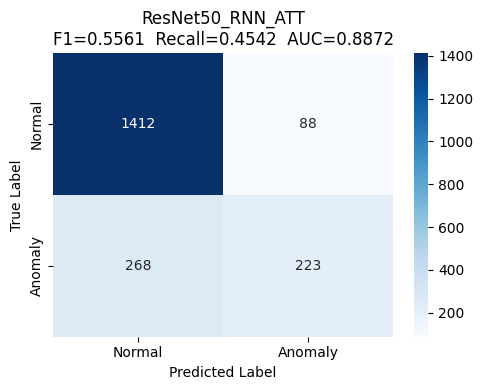

ResNet50_RNN_ATT: F1=0.5561  Prec=0.7170  Rec=0.4542  Acc=0.8212  SeqAUC=0.8872  FrameAUC=0.8890
              precision    recall  f1-score   support

      Normal       0.84      0.94      0.89      1500
     Anomaly       0.72      0.45      0.56       491

    accuracy                           0.82      1991
   macro avg       0.78      0.70      0.72      1991
weighted avg       0.81      0.82      0.81      1991



In [27]:
r50_rnn_model = load_best_checkpoint('ResNet50_RNN_ATT', CONFIG['resnet50_feat_dim'], 'RNN', hp_r50_rnn)
r50_rnn_eval = evaluate_model(
    r50_rnn_model, test_ds_r, y_test_balanced,
    model_name    = 'ResNet50_RNN_ATT',
    test_seqs_bal = test_seqs_balanced,
    gt_labels     = GT_LABELS,
    threshold     = r50_rnn_thresh
)
all_histories.append(('ResNet50_RNN_ATT', r50_rnn_history))
all_eval_results['ResNet50_RNN_ATT'] = r50_rnn_eval

## 17. Model — ResNet50_GRU_ATT

In [28]:
hp_r50_gru = MODEL_HPS['ResNet50_GRU_ATT']
r50_gru_model, r50_gru_history, _, r50_gru_thresh = train_model(
    rnn_type   = 'GRU',
    feat_dim   = CONFIG['resnet50_feat_dim'],
    train_ds   = train_ds_r,
    val_ds     = val_ds_r,
    model_name = 'ResNet50_GRU_ATT',
    y_val_arr  = y_val,
    hp         = hp_r50_gru
)


  Training: ResNet50_GRU_ATT  |  backbone=ResNet50  rnn=GRU  feat=2048
  LR=0.0005  dropout=0.4  epochs=25


Model: "GRU_ATT_2048d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)      │ (None, 16, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_embedding (Dense)         │ (None, 16, 512)        │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_drop (Dropout)             │ (None, 16, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_embed                       │ (None, 16, 512)        │         8,192 │
│ (PositionalEmbeddingLayer)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16, 256)        │       591,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 16, 256)        │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ additive_attn                   │ (None, 256)            │           257 │
│ (AdditiveAttentionLayer)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_drop (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,076,674 (7.92 MB)

 Trainable params: 2,076,674 (7.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5500 - loss: 0.3973 - val_accuracy: 0.8024 - val_loss: 0.1321 - learning_rate: 5.0000e-04
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8135 - loss: 0.2059 - val_accuracy: 0.6738 - val_loss: 0.2384 - learning_rate: 5.0000e-04
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8206 - loss: 0.1823 - val_accuracy: 0.8241 - val_loss: 0.1118 - learning_rate: 5.0000e-04
Epoch 4/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8548 - loss: 0.1400 - val_accuracy: 0.9257 - val_loss: 0.0665 - learning_rate: 5.0000e-04
Epoch 5/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9023 - loss: 0.1198 - val_accuracy: 0.8639 - val_loss: 0.0897 - learning_rate: 5.0000e-04
Epoch 6/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8861 - loss: 0.1112 - val_accuracy: 0.9564 - val_loss: 0.0391 - learning_rate: 5.0000e-04
Epoch 7/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc

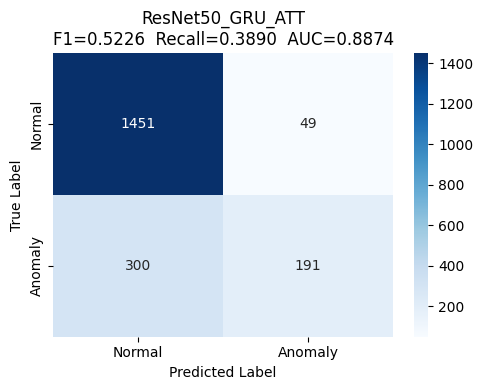

ResNet50_GRU_ATT: F1=0.5226  Prec=0.7958  Rec=0.3890  Acc=0.8247  SeqAUC=0.8874  FrameAUC=0.8873
              precision    recall  f1-score   support

      Normal       0.83      0.97      0.89      1500
     Anomaly       0.80      0.39      0.52       491

    accuracy                           0.82      1991
   macro avg       0.81      0.68      0.71      1991
weighted avg       0.82      0.82      0.80      1991



In [29]:
r50_gru_model = load_best_checkpoint('ResNet50_GRU_ATT', CONFIG['resnet50_feat_dim'], 'GRU', hp_r50_gru)
r50_gru_eval = evaluate_model(
    r50_gru_model, test_ds_r, y_test_balanced,
    model_name    = 'ResNet50_GRU_ATT',
    test_seqs_bal = test_seqs_balanced,
    gt_labels     = GT_LABELS,
    threshold     = r50_gru_thresh
)
all_histories.append(('ResNet50_GRU_ATT', r50_gru_history))
all_eval_results['ResNet50_GRU_ATT'] = r50_gru_eval

## 18. Model — ResNet50_LSTM_ATT

In [30]:
hp_r50_lstm = MODEL_HPS['ResNet50_LSTM_ATT']
r50_lstm_model, r50_lstm_history, _, r50_lstm_thresh = train_model(
    rnn_type   = 'LSTM',
    feat_dim   = CONFIG['resnet50_feat_dim'],
    train_ds   = train_ds_r,
    val_ds     = val_ds_r,
    model_name = 'ResNet50_LSTM_ATT',
    y_val_arr  = y_val,
    hp         = hp_r50_lstm
)


  Training: ResNet50_LSTM_ATT  |  backbone=ResNet50  rnn=LSTM  feat=2048
  LR=0.0005  dropout=0.4  epochs=25


Model: "LSTM_ATT_2048d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)      │ (None, 16, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_embedding (Dense)         │ (None, 16, 512)        │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_drop (Dropout)             │ (None, 16, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_embed                       │ (None, 16, 512)        │         8,192 │
│ (PositionalEmbeddingLayer)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16, 256)        │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ additive_attn                   │ (None, 256)            │           257 │
│ (AdditiveAttentionLayer)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_drop (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,403,330 (9.17 MB)

 Trainable params: 2,403,330 (9.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5618 - loss: 0.3449 - val_accuracy: 0.9610 - val_loss: 0.0367 - learning_rate: 5.0000e-04
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8179 - loss: 0.2170 - val_accuracy: 0.8933 - val_loss: 0.0748 - learning_rate: 5.0000e-04
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8407 - loss: 0.1762 - val_accuracy: 0.8823 - val_loss: 0.0703 - learning_rate: 5.0000e-04
Epoch 4/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8612 - loss: 0.1638 - val_accuracy: 0.8535 - val_loss: 0.0857 - learning_rate: 5.0000e-04
Epoch 5/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8856 - loss: 0.1259 - val_accuracy: 0.8610 - val_loss: 0.1065 - learning_rate: 5.0000e-04
Epoch 6/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8855 - loss: 0.1186
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy

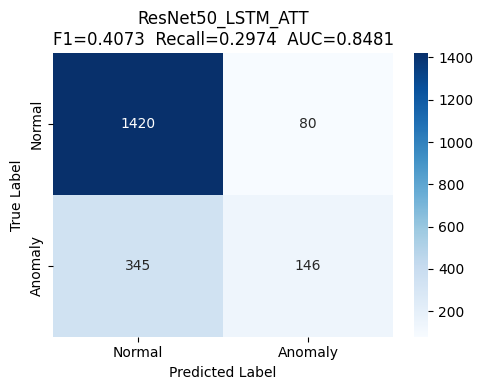

ResNet50_LSTM_ATT: F1=0.4073  Prec=0.6460  Rec=0.2974  Acc=0.7865  SeqAUC=0.8481  FrameAUC=0.8468
              precision    recall  f1-score   support

      Normal       0.80      0.95      0.87      1500
     Anomaly       0.65      0.30      0.41       491

    accuracy                           0.79      1991
   macro avg       0.73      0.62      0.64      1991
weighted avg       0.77      0.79      0.76      1991



In [31]:
r50_lstm_model = load_best_checkpoint('ResNet50_LSTM_ATT', CONFIG['resnet50_feat_dim'], 'LSTM', hp_r50_lstm)
r50_lstm_eval = evaluate_model(
    r50_lstm_model, test_ds_r, y_test_balanced,
    model_name    = 'ResNet50_LSTM_ATT',
    test_seqs_bal = test_seqs_balanced,
    gt_labels     = GT_LABELS,
    threshold     = r50_lstm_thresh
)
all_histories.append(('ResNet50_LSTM_ATT', r50_lstm_history))
all_eval_results['ResNet50_LSTM_ATT'] = r50_lstm_eval

## 19. Model — DenseNet_RNN_ATT

In [32]:
hp_dn_rnn = MODEL_HPS['DenseNet_RNN_ATT']
dn_rnn_model, dn_rnn_history, _, dn_rnn_thresh = train_model(
    rnn_type   = 'RNN',
    feat_dim   = CONFIG['densenet121_feat_dim'],
    train_ds   = train_ds_d,
    val_ds     = val_ds_d,
    model_name = 'DenseNet_RNN_ATT',
    y_val_arr  = y_val,
    hp         = hp_dn_rnn
)


  Training: DenseNet_RNN_ATT  |  backbone=DenseNet121  rnn=RNN  feat=1024
  LR=0.0005  dropout=0.4  epochs=25


Model: "RNN_ATT_1024d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)      │ (None, 16, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_embedding (Dense)         │ (None, 16, 512)        │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_drop (Dropout)             │ (None, 16, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_embed                       │ (None, 16, 512)        │         8,192 │
│ (PositionalEmbeddingLayer)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ (None, 16, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (SimpleRNN)               │ (None, 16, 256)        │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ additive_attn                   │ (None, 256)            │           257 │
│ (AdditiveAttentionLayer)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_drop (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 894,466 (3.41 MB)

 Trainable params: 894,466 (3.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.4828 - loss: 0.4891 - val_accuracy: 0.7647 - val_loss: 0.1243 - learning_rate: 5.0000e-04
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.6640 - loss: 0.3066 - val_accuracy: 0.7981 - val_loss: 0.1680 - learning_rate: 5.0000e-04
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.7988 - loss: 0.2165 - val_accuracy: 0.8584 - val_loss: 0.1243 - learning_rate: 5.0000e-04
Epoch 4/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8476 - loss: 0.1775 - val_accuracy: 0.8452 - val_loss: 0.1625 - learning_rate: 5.0000e-04
Epoch 5/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8901 - loss: 0.1345 - val_accuracy: 0.8754 - val_loss: 0.1198 - learning_rate: 5.0000e-04
Epoch 6/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8874 - loss: 0.1380 - val_accuracy: 0.8698 - val_loss: 0.1192 - learning_rate: 5.0000e-04
Epoch 7/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - ac

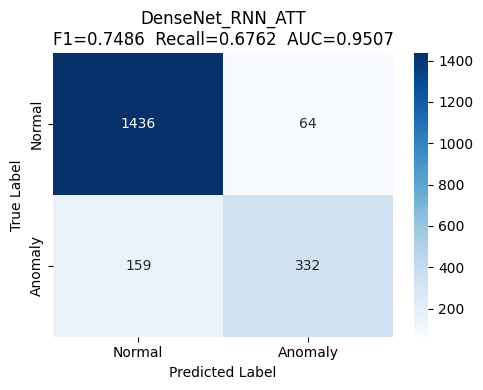

DenseNet_RNN_ATT: F1=0.7486  Prec=0.8384  Rec=0.6762  Acc=0.8880  SeqAUC=0.9507  FrameAUC=0.9521
              precision    recall  f1-score   support

      Normal       0.90      0.96      0.93      1500
     Anomaly       0.84      0.68      0.75       491

    accuracy                           0.89      1991
   macro avg       0.87      0.82      0.84      1991
weighted avg       0.89      0.89      0.88      1991



In [33]:
dn_rnn_model = load_best_checkpoint('DenseNet_RNN_ATT', CONFIG['densenet121_feat_dim'], 'RNN', hp_dn_rnn)
dn_rnn_eval = evaluate_model(
    dn_rnn_model, test_ds_d, y_test_balanced,
    model_name    = 'DenseNet_RNN_ATT',
    test_seqs_bal = test_seqs_balanced,
    gt_labels     = GT_LABELS,
    threshold     = dn_rnn_thresh
)
all_histories.append(('DenseNet_RNN_ATT', dn_rnn_history))
all_eval_results['DenseNet_RNN_ATT'] = dn_rnn_eval

## 20. Model — DenseNet_GRU_ATT

In [34]:
hp_dn_gru = MODEL_HPS['DenseNet_GRU_ATT']
dn_gru_model, dn_gru_history, _, dn_gru_thresh = train_model(
    rnn_type   = 'GRU',
    feat_dim   = CONFIG['densenet121_feat_dim'],
    train_ds   = train_ds_d,
    val_ds     = val_ds_d,
    model_name = 'DenseNet_GRU_ATT',
    y_val_arr  = y_val,
    hp         = hp_dn_gru
)


  Training: DenseNet_GRU_ATT  |  backbone=DenseNet121  rnn=GRU  feat=1024
  LR=0.0005  dropout=0.4  epochs=25


Model: "GRU_ATT_1024d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)      │ (None, 16, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_embedding (Dense)         │ (None, 16, 512)        │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_drop (Dropout)             │ (None, 16, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_embed                       │ (None, 16, 512)        │         8,192 │
│ (PositionalEmbeddingLayer)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16, 256)        │       591,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 16, 256)        │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ additive_attn                   │ (None, 256)            │           257 │
│ (AdditiveAttentionLayer)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_drop (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,552,386 (5.92 MB)

 Trainable params: 1,552,386 (5.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.4408 - loss: 0.4551 - val_accuracy: 0.1246 - val_loss: 0.6458 - learning_rate: 5.0000e-04
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6615 - loss: 0.2980 - val_accuracy: 0.4656 - val_loss: 0.5179 - learning_rate: 5.0000e-04
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7662 - loss: 0.2327 - val_accuracy: 0.9276 - val_loss: 0.0431 - learning_rate: 5.0000e-04
Epoch 4/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8567 - loss: 0.1554 - val_accuracy: 0.8811 - val_loss: 0.0933 - learning_rate: 5.0000e-04
Epoch 5/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8824 - loss: 0.1272 - val_accuracy: 0.9724 - val_loss: 0.0295 - learning_rate: 5.0000e-04
Epoch 6/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9037 - loss: 0.1248 - val_accuracy: 0.9318 - val_loss: 0.0673 - learning_rate: 5.0000e-04
Epoch 7/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc

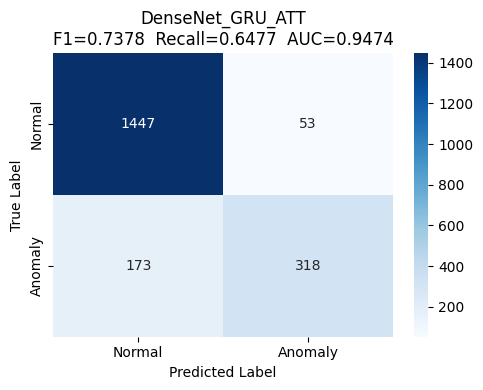

DenseNet_GRU_ATT: F1=0.7378  Prec=0.8571  Rec=0.6477  Acc=0.8865  SeqAUC=0.9474  FrameAUC=0.9499
              precision    recall  f1-score   support

      Normal       0.89      0.96      0.93      1500
     Anomaly       0.86      0.65      0.74       491

    accuracy                           0.89      1991
   macro avg       0.88      0.81      0.83      1991
weighted avg       0.88      0.89      0.88      1991



In [35]:
dn_gru_model = load_best_checkpoint('DenseNet_GRU_ATT', CONFIG['densenet121_feat_dim'], 'GRU', hp_dn_gru)
dn_gru_eval = evaluate_model(
    dn_gru_model, test_ds_d, y_test_balanced,
    model_name    = 'DenseNet_GRU_ATT',
    test_seqs_bal = test_seqs_balanced,
    gt_labels     = GT_LABELS,
    threshold     = dn_gru_thresh
)
all_histories.append(('DenseNet_GRU_ATT', dn_gru_history))
all_eval_results['DenseNet_GRU_ATT'] = dn_gru_eval

## 21. Model — DenseNet_LSTM_ATT

In [36]:
hp_dn_lstm = MODEL_HPS['DenseNet_LSTM_ATT']
dn_lstm_model, dn_lstm_history, _, dn_lstm_thresh = train_model(
    rnn_type   = 'LSTM',
    feat_dim   = CONFIG['densenet121_feat_dim'],
    train_ds   = train_ds_d,
    val_ds     = val_ds_d,
    model_name = 'DenseNet_LSTM_ATT',
    y_val_arr  = y_val,
    hp         = hp_dn_lstm
)


  Training: DenseNet_LSTM_ATT  |  backbone=DenseNet121  rnn=LSTM  feat=1024
  LR=0.0005  dropout=0.4  epochs=25


Model: "LSTM_ATT_1024d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)      │ (None, 16, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_embedding (Dense)         │ (None, 16, 512)        │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_drop (Dropout)             │ (None, 16, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_embed                       │ (None, 16, 512)        │         8,192 │
│ (PositionalEmbeddingLayer)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16, 256)        │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ additive_attn                   │ (None, 256)            │           257 │
│ (AdditiveAttentionLayer)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_drop (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,879,042 (7.17 MB)

 Trainable params: 1,879,042 (7.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.4462 - loss: 0.4338 - val_accuracy: 0.9215 - val_loss: 0.0459 - learning_rate: 5.0000e-04
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7406 - loss: 0.2595 - val_accuracy: 0.9462 - val_loss: 0.0371 - learning_rate: 5.0000e-04
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8367 - loss: 0.1912 - val_accuracy: 0.8886 - val_loss: 0.0642 - learning_rate: 5.0000e-04
Epoch 4/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8239 - loss: 0.1706 - val_accuracy: 0.6011 - val_loss: 0.2694 - learning_rate: 5.0000e-04
Epoch 5/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8653 - loss: 0.1420 - val_accuracy: 0.9188 - val_loss: 0.0703 - learning_rate: 5.0000e-04
Epoch 6/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9012 - loss: 0.1170 - val_accuracy: 0.9574 - val_loss: 0.0374 - learning_rate: 5.0000e-04
Epoch 7/25
146/148 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc

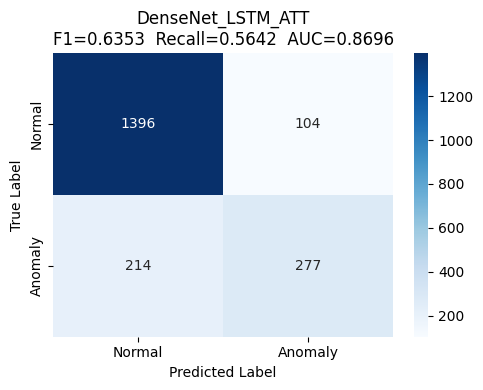

DenseNet_LSTM_ATT: F1=0.6353  Prec=0.7270  Rec=0.5642  Acc=0.8403  SeqAUC=0.8696  FrameAUC=0.8770
              precision    recall  f1-score   support

      Normal       0.87      0.93      0.90      1500
     Anomaly       0.73      0.56      0.64       491

    accuracy                           0.84      1991
   macro avg       0.80      0.75      0.77      1991
weighted avg       0.83      0.84      0.83      1991



In [37]:
dn_lstm_model = load_best_checkpoint('DenseNet_LSTM_ATT', CONFIG['densenet121_feat_dim'], 'LSTM', hp_dn_lstm)
dn_lstm_eval = evaluate_model(
    dn_lstm_model, test_ds_d, y_test_balanced,
    model_name    = 'DenseNet_LSTM_ATT',
    test_seqs_bal = test_seqs_balanced,
    gt_labels     = GT_LABELS,
    threshold     = dn_lstm_thresh
)
all_histories.append(('DenseNet_LSTM_ATT', dn_lstm_history))
all_eval_results['DenseNet_LSTM_ATT'] = dn_lstm_eval

## 22. Training History

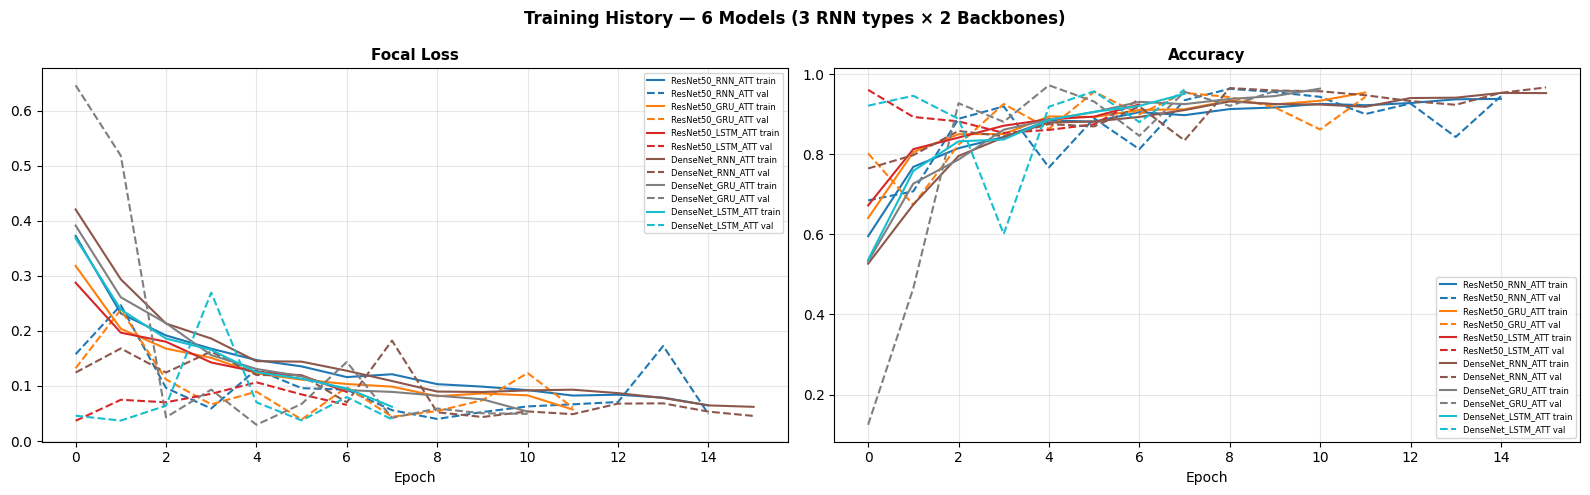

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_histories)))

for (name, hist), c in zip(all_histories, colors):
    axes[0].plot(hist['loss'],         color=c,       label=f'{name} train')
    axes[0].plot(hist['val_loss'], ls='--', color=c,  label=f'{name} val')
    axes[1].plot(hist['accuracy'],     color=c,       label=f'{name} train')
    axes[1].plot(hist['val_accuracy'], ls='--', color=c, label=f'{name} val')

for ax, title in zip(axes, ['Focal Loss', 'Accuracy']):
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(fontsize=6); ax.grid(alpha=0.3)

plt.suptitle('Training History — 6 Models (3 RNN types × 2 Backbones)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'training_history.png'), dpi=150)
plt.show()

## 23. ROC Curves — All Models

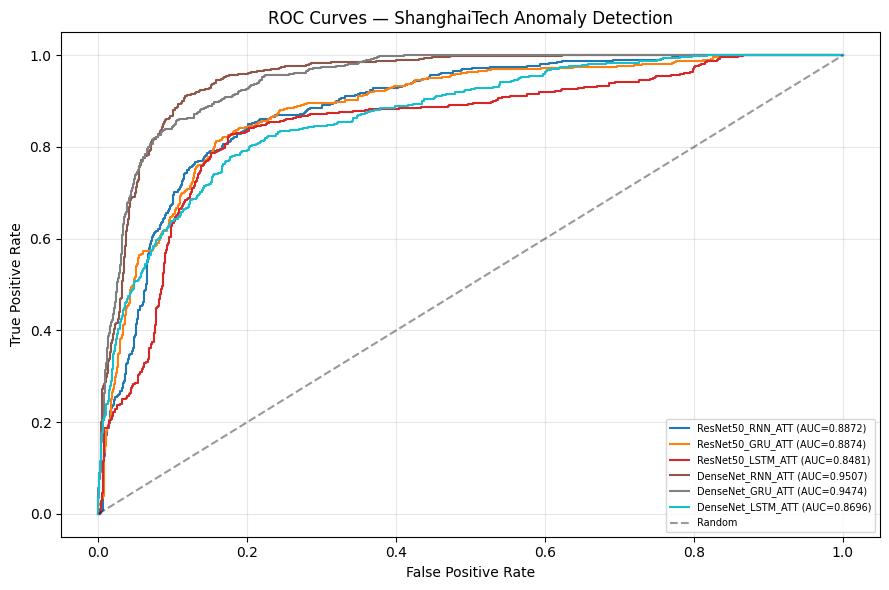

In [39]:
plt.figure(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_eval_results)))
for (name, r), c in zip(all_eval_results.items(), colors):
    plt.plot(r['fpr'], r['tpr'], color=c, label=f'{name} (AUC={r["seq_auc"]:.4f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — ShanghaiTech Anomaly Detection')
plt.legend(fontsize=7); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'roc_curves.png'), dpi=150)
plt.show()

## 24. Model Comparison — All Metrics

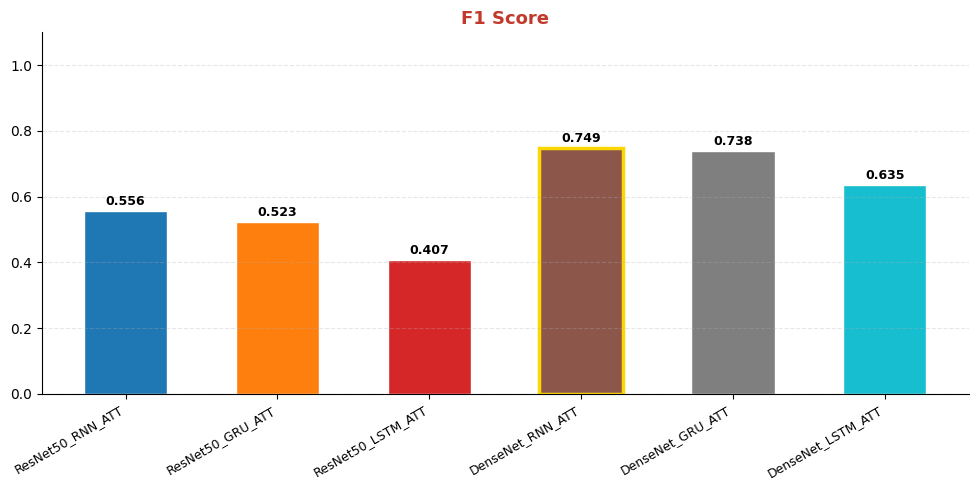

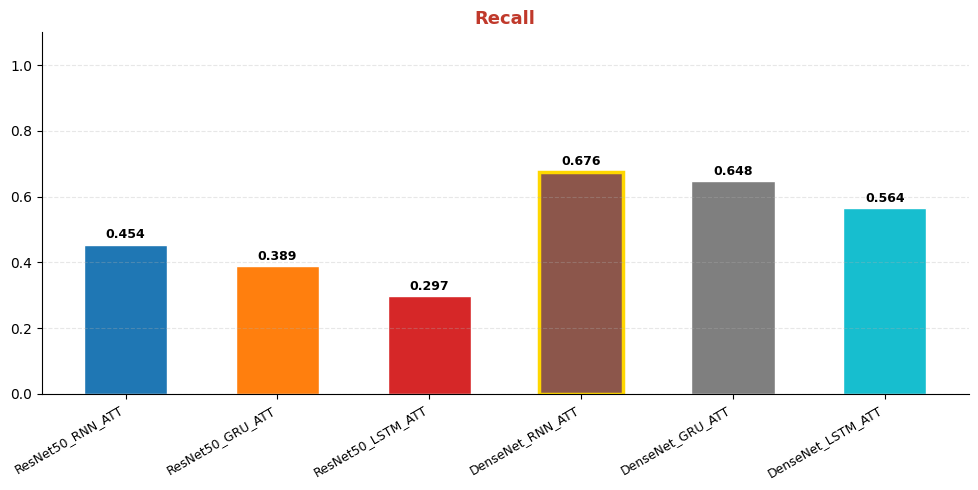

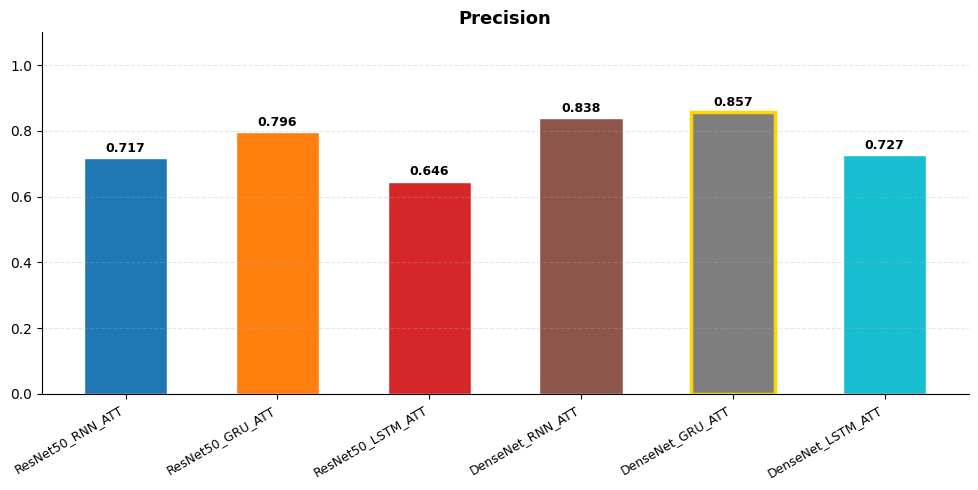

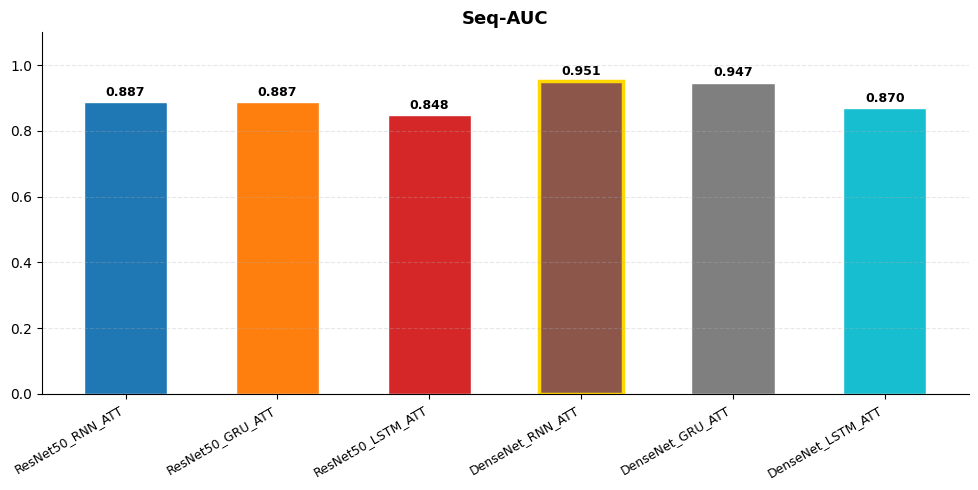

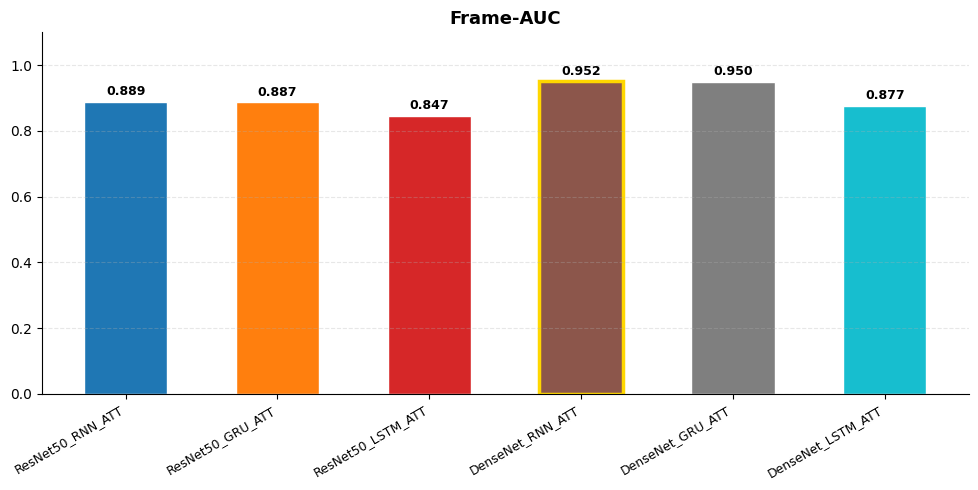

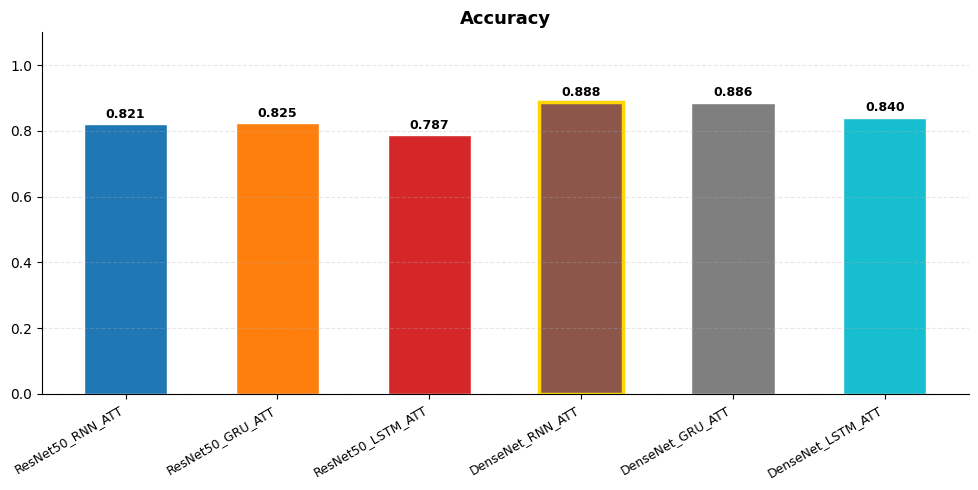

In [40]:
metrics_list  = ['f1', 'recall', 'precision', 'seq_auc', 'frame_auc', 'accuracy']
metric_labels = ['F1 Score', 'Recall', 'Precision', 'Seq-AUC', 'Frame-AUC', 'Accuracy']
model_names   = list(all_eval_results.keys())
colors        = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))
x_positions   = np.arange(len(model_names))

for metric, mlabel in zip(metrics_list, metric_labels):

    values = []
    for name in model_names:
        values.append(all_eval_results[name][metric])

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(x_positions, values, color=colors, width=0.55, edgecolor='white')

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

    if metric in ('f1', 'recall'):
        title_color = '#c0392b'
    else:
        title_color = 'black'

    ax.set_title(mlabel, fontsize=13, fontweight='bold', color=title_color)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0.0, 1.10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    best_idx = int(np.argmax(values))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['plots_dir'], f'chart_{metric}.png'), dpi=150)
    plt.show()

## 25. Final Results Table & Analysis

In [41]:
backbone_map = {
    'ResNet50_RNN_ATT'  : 'ResNet50',
    'ResNet50_GRU_ATT'  : 'ResNet50',
    'ResNet50_LSTM_ATT' : 'ResNet50',
    'DenseNet_RNN_ATT'  : 'DenseNet121',
    'DenseNet_GRU_ATT'  : 'DenseNet121',
    'DenseNet_LSTM_ATT' : 'DenseNet121',
}
rnn_map = {
    'ResNet50_RNN_ATT'  : 'RNN',
    'ResNet50_GRU_ATT'  : 'GRU',
    'ResNet50_LSTM_ATT' : 'LSTM',
    'DenseNet_RNN_ATT'  : 'RNN',
    'DenseNet_GRU_ATT'  : 'GRU',
    'DenseNet_LSTM_ATT' : 'LSTM',
}

print('='*110)
print('  FINAL RESULTS — CNN Backbone + Temporal Architecture Comparison')
print('  All 6 models: identical LR=5e-4, dropout=0.4, seq_len=16')
print('  Only backbone and RNN type differ — fair comparison')
print('='*110)
print(f'{"Model":<24} {"Backbone":<14} {"RNN":>5} {"F1":>8} {"Recall":>8} {"Precision":>10} {"AUC":>8} {"FrameAUC":>10}')
print('-'*110)

groups = [
    ('ResNet50 Backbone (fine-tuned conv5)',         ['ResNet50_RNN_ATT',  'ResNet50_GRU_ATT',  'ResNet50_LSTM_ATT']),
    ('DenseNet121 Backbone (fine-tuned denseblock4)', ['DenseNet_RNN_ATT',  'DenseNet_GRU_ATT',  'DenseNet_LSTM_ATT']),
]

for grp_label, names in groups:
    print(f'  -- {grp_label}')
    for n in names:
        if n not in all_eval_results:
            continue
        r = all_eval_results[n]
        print(
            f'  {n:<24} {backbone_map[n]:<14} {rnn_map[n]:>5} '
            f'{r["f1"]:>8.4f} {r["recall"]:>8.4f} '
            f'{r["precision"]:>10.4f} {r["seq_auc"]:>8.4f} {r["frame_auc"]:>10.4f}'
        )
    print()

print('='*110)

# Find best model by F1
best_f1_name  = None
best_f1_val   = -1.0
best_auc_name = None
best_auc_val  = -1.0

for name, r in all_eval_results.items():
    if r['f1'] > best_f1_val:
        best_f1_val  = r['f1']
        best_f1_name = name
    if r['seq_auc'] > best_auc_val:
        best_auc_val  = r['seq_auc']
        best_auc_name = name

print(f'  Best F1      : {best_f1_name}  (F1={best_f1_val:.4f})')
print(f'  Best AUC     : {best_auc_name}  (AUC={best_auc_val:.4f})')

# Temporal architecture comparison: same backbone, different RNN
print('\n  Temporal architecture comparison (DenseNet121, fixed):')
for rnn in ['RNN', 'GRU', 'LSTM']:
    n = f'DenseNet_{rnn}_ATT'
    if n in all_eval_results:
        r = all_eval_results[n]
        print(f'    {rnn:<5}  F1={r["f1"]:.4f}  Recall={r["recall"]:.4f}  AUC={r["seq_auc"]:.4f}')

# Backbone comparison: same RNN=LSTM, different backbone
print('\n  Backbone comparison (LSTM, fixed):')
for name in ['ResNet50_LSTM_ATT', 'DenseNet_LSTM_ATT']:
    if name in all_eval_results:
        r = all_eval_results[name]
        print(f'    {name:<24}  F1={r["f1"]:.4f}  AUC={r["seq_auc"]:.4f}')

# Ranked list by F1
print('\n  Ranked by F1 Score:')
ranked = []
for name, r in all_eval_results.items():
    ranked.append((name, r))
# Sort by F1 score descending — manual swap sort to avoid lambda
for i in range(len(ranked)):
    for j in range(i + 1, len(ranked)):
        if ranked[j][1]['f1'] > ranked[i][1]['f1']:
            ranked[i], ranked[j] = ranked[j], ranked[i]

for rank, (name, r) in enumerate(ranked, 1):
    bar = '█' * int(r['f1'] * 30)
    print(
        f'  {rank}. {name:<24}  F1={r["f1"]:.4f}  Recall={r["recall"]:.4f}  '
        f'Prec={r["precision"]:.4f}  {bar}'
    )


  FINAL RESULTS — CNN Backbone + Temporal Architecture Comparison
  All 6 models: identical LR=5e-4, dropout=0.4, seq_len=16
  Only backbone and RNN type differ — fair comparison
Model                    Backbone         RNN       F1   Recall  Precision      AUC   FrameAUC
--------------------------------------------------------------------------------------------------------------
  -- ResNet50 Backbone (fine-tuned conv5)
  ResNet50_RNN_ATT         ResNet50         RNN   0.5561   0.4542     0.7170   0.8872     0.8890
  ResNet50_GRU_ATT         ResNet50         GRU   0.5226   0.3890     0.7958   0.8874     0.8873
  ResNet50_LSTM_ATT        ResNet50        LSTM   0.4073   0.2974     0.6460   0.8481     0.8468

  -- DenseNet121 Backbone (fine-tuned denseblock4)
  DenseNet_RNN_ATT         DenseNet121      RNN   0.7486   0.6762     0.8384   0.9507     0.9521
  DenseNet_GRU_ATT         DenseNet121      GRU   0.7378   0.6477     0.8571   0.9474     0.9499
  DenseNet_LSTM_ATT        DenseNet1